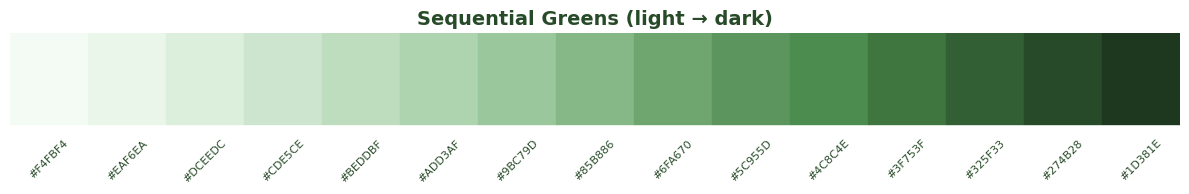

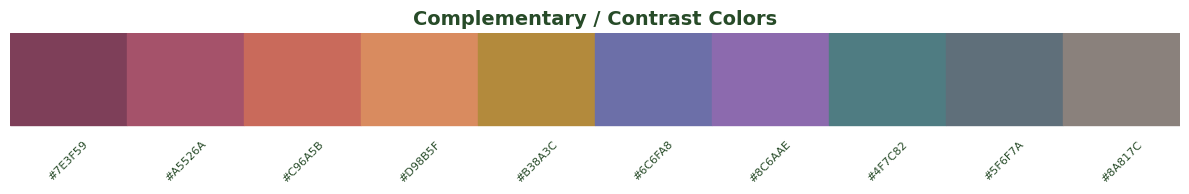

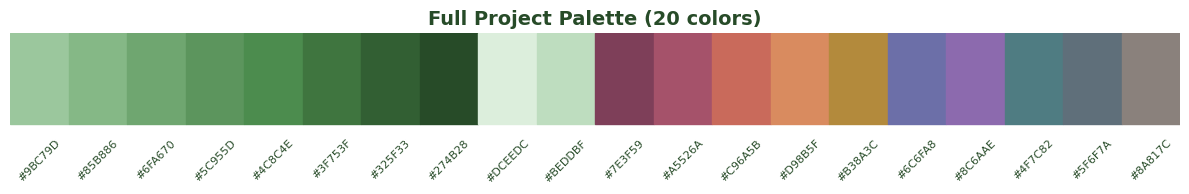

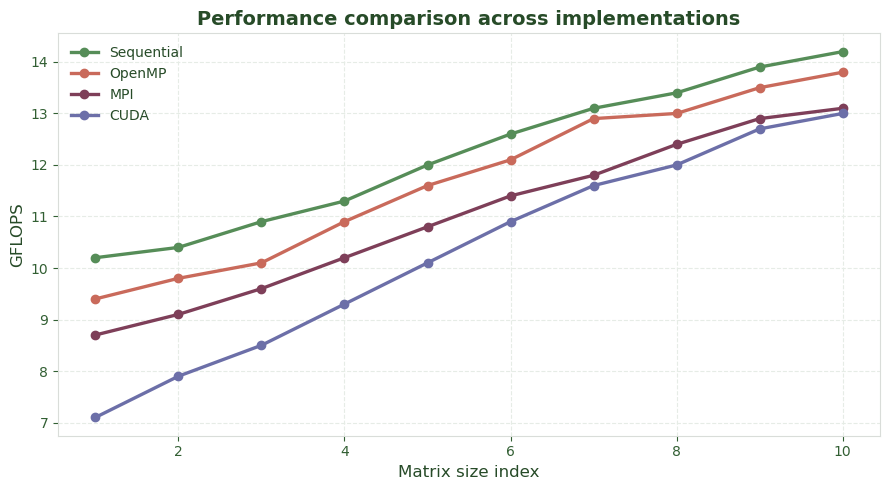

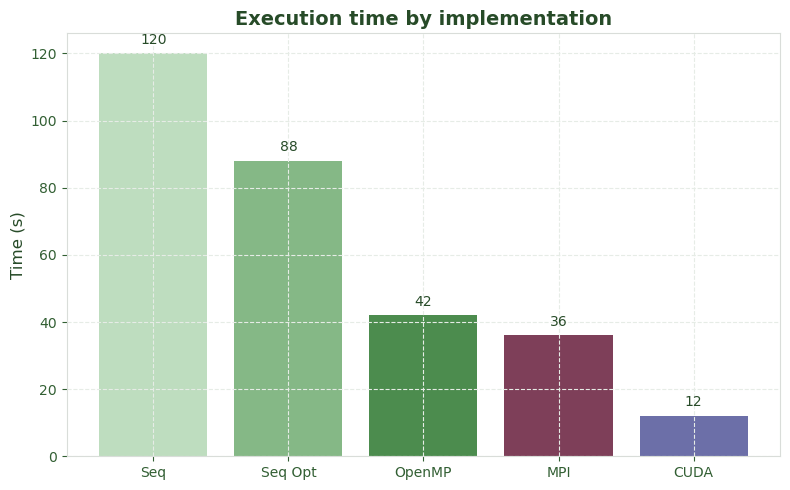

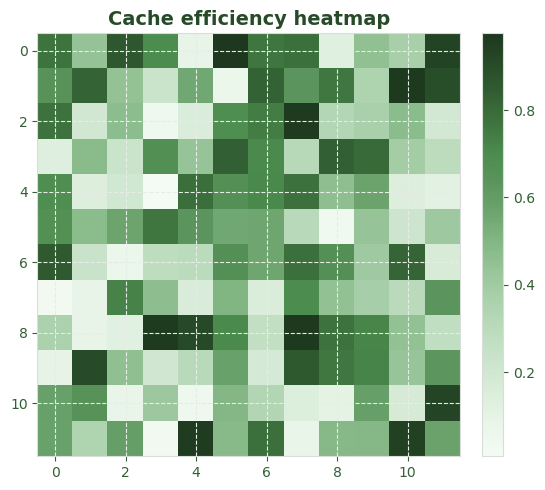

In [ ]:
# ============================================
# HPC Project Palette
# Inspired by your LaTeX greens
# ============================================

from matplotlib.colors import LinearSegmentedColormap, ListedColormap
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

# -----------------------------
# 1) Core brand colors
# -----------------------------
MAIN_GREEN   = "#9BC79D"   # RGB(155, 199, 157)
DARK_GREEN   = "#568D58"   # RGB(86, 141, 88)
ACCENT_GREEN = "#4C8C4E"   # RGB(76, 140, 78)

# -----------------------------
# 2) Sequential green palette
#    Light -> dark
#    Good for: heatmaps, gradients, intensity
# -----------------------------
greens_light_to_dark = [
    "#F4FBF4",
    "#EAF6EA",
    "#DCEEDC",
    "#CDE5CE",
    "#BEDDBF",
    "#ADD3AF",
    "#9BC79D",  # MAIN_GREEN
    "#85B886",
    "#6FA670",
    "#5C955D",
    "#4C8C4E",  # ACCENT_GREEN
    "#3F753F",
    "#325F33",
    "#274B28",
    "#1D381E"
]

# -----------------------------
# 3) Complementary / contrast palette
#    Built to pair well with green
#    Good for: multiple series, categories, highlights
# -----------------------------
complementary_colors = [
    "#7E3F59",  # dusty burgundy
    "#A5526A",  # muted raspberry
    "#C96A5B",  # terracotta
    "#D98B5F",  # warm amber
    "#B38A3C",  # olive gold
    "#6C6FA8",  # muted indigo
    "#8C6AAE",  # soft violet
    "#4F7C82",  # desaturated teal
    "#5F6F7A",  # blue-gray
    "#8A817C"   # warm gray
]

# -----------------------------
# 4) Full categorical palette
#    20+ colors for many series
# -----------------------------
project_palette_20 = [
    "#9BC79D", "#85B886", "#6FA670", "#5C955D", "#4C8C4E",
    "#3F753F", "#325F33", "#274B28", "#DCEEDC", "#BEDDBF",
    "#7E3F59", "#A5526A", "#C96A5B", "#D98B5F", "#B38A3C",
    "#6C6FA8", "#8C6AAE", "#4F7C82", "#5F6F7A", "#8A817C"
]

# Optional extended version (25 colors)
project_palette_25 = project_palette_20 + [
    "#EAF6EA",
    "#ADD3AF",
    "#729C91",
    "#B9748C",
    "#A39B8B"
]

# -----------------------------
# 5) Matplotlib colormaps
# -----------------------------
green_cmap = LinearSegmentedColormap.from_list(
    "hpc_green_cmap",
    greens_light_to_dark
)

categorical_cmap = ListedColormap(project_palette_20, name="hpc_project_20")

# -----------------------------
# 6) Global plotting style
# -----------------------------
mpl.rcParams.update({
    "axes.facecolor": "white",
    "figure.facecolor": "white",
    "axes.edgecolor": "#D9DDD9",
    "axes.labelcolor": "#274B28",
    "xtick.color": "#325F33",
    "ytick.color": "#325F33",
    "text.color": "#274B28",
    "axes.titleweight": "bold",
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.frameon": False,
    "grid.color": "#E6ECE6",
    "grid.linestyle": "--",
    "grid.linewidth": 0.8,
    "axes.grid": True,
    "lines.linewidth": 2.4
})

# -----------------------------
# 7) Helper: preview palette
# -----------------------------
def show_palette(colors, title="Palette Preview", figsize=(12, 2)):
    fig, ax = plt.subplots(figsize=figsize)
    for i, c in enumerate(colors):
        ax.add_patch(plt.Rectangle((i, 0), 1, 1, color=c))
        ax.text(i + 0.5, -0.15, c, ha="center", va="top", fontsize=8, rotation=45)
    ax.set_xlim(0, len(colors))
    ax.set_ylim(-0.35, 1)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title)
    for spine in ax.spines.values():
        spine.set_visible(False)
    plt.tight_layout()
    plt.show()

# -----------------------------
# 8) Example 1: line plot
# -----------------------------
def example_line_plot():
    x = np.arange(1, 11)
    series = {
        "Sequential": np.array([10.2, 10.4, 10.9, 11.3, 12.0, 12.6, 13.1, 13.4, 13.9, 14.2]),
        "OpenMP":     np.array([9.4, 9.8, 10.1, 10.9, 11.6, 12.1, 12.9, 13.0, 13.5, 13.8]),
        "MPI":        np.array([8.7, 9.1, 9.6, 10.2, 10.8, 11.4, 11.8, 12.4, 12.9, 13.1]),
        "CUDA":       np.array([7.1, 7.9, 8.5, 9.3, 10.1, 10.9, 11.6, 12.0, 12.7, 13.0]),
    }

    colors = ["#568D58",  "#C96A5B", "#7E3F59", "#6C6FA8"]

    fig, ax = plt.subplots(figsize=(9, 5))
    for (label, y), c in zip(series.items(), colors):
        ax.plot(x, y, marker="o", color=c, label=label)

    ax.set_title("Performance comparison across implementations")
    ax.set_xlabel("Matrix size index")
    ax.set_ylabel("GFLOPS")
    ax.legend()
    plt.tight_layout()
    plt.show()

# -----------------------------
# 9) Example 2: bar plot
# -----------------------------
def example_bar_plot():
    labels = ["Seq", "Seq Opt", "OpenMP", "MPI", "CUDA"]
    values = [120, 88, 42, 36, 12]
    colors = [greens_light_to_dark[4], greens_light_to_dark[7], ACCENT_GREEN, "#7E3F59", "#6C6FA8"]

    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(labels, values, color=colors)

    ax.set_title("Execution time by implementation")
    ax.set_ylabel("Time (s)")

    for b in bars:
        h = b.get_height()
        ax.text(b.get_x() + b.get_width()/2, h + 2, f"{h:.0f}", ha="center", va="bottom")

    plt.tight_layout()
    plt.show()

# -----------------------------
# 10) Example 3: heatmap-like imshow
# -----------------------------
def example_heatmap():
    rng = np.random.default_rng(42)
    data = rng.random((12, 12))

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(data, cmap=green_cmap)
    ax.set_title("Cache efficiency heatmap")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

# -----------------------------
# 11) Preview everything
# -----------------------------
if __name__ == "__main__":
    show_palette(greens_light_to_dark, "Sequential Greens (light → dark)")
    show_palette(complementary_colors, "Complementary / Contrast Colors")
    show_palette(project_palette_20, "Full Project Palette (20 colors)")

    example_line_plot()
    example_bar_plot()
    example_heatmap()

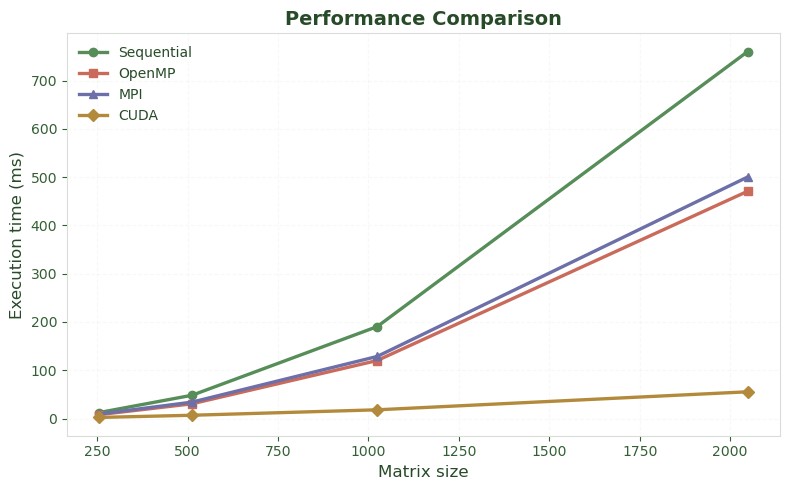

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# performance_colors = {
#     "Sequential": "#568D58",
#     "OpenMP":     "#4C8C4E",
#     "MPI":        "#7E3F59",
#     "CUDA":       "#6C6FA8"
# }
performance_colors = {
    "Sequential": "#568D58",   # green
    "OpenMP":     "#C96A5B",   # terracotta
    "MPI":        "#6C6FA8",   # muted indigo
    "CUDA":       "#B38A3C"    # olive gold
}
x = np.array([256, 512, 1024, 2048])
seq   = [12.5, 48.2, 190.4, 760.1]
omp   = [8.1, 30.5, 120.2, 470.8]
mpi   = [9.4, 34.0, 128.6, 500.3]
cuda  = [2.3, 6.8, 18.1, 55.4]

plt.figure(figsize=(8,5))
plt.plot(x, seq,  marker="o", label="Sequential", color=performance_colors["Sequential"])
plt.plot(x, omp,  marker="s", label="OpenMP",     color=performance_colors["OpenMP"])
plt.plot(x, mpi,  marker="^", label="MPI",        color=performance_colors["MPI"])
plt.plot(x, cuda, marker="D", label="CUDA",       color=performance_colors["CUDA"])

plt.xlabel("Matrix size")
plt.ylabel("Execution time (ms)")
plt.title("Performance Comparison")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

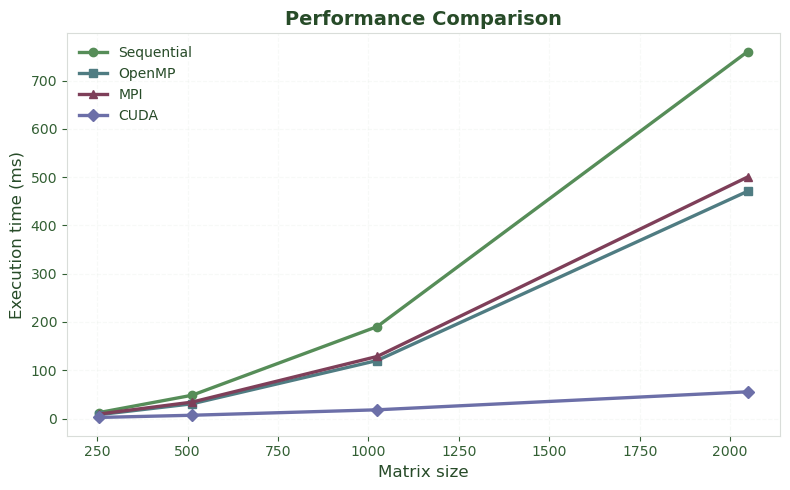

In [3]:
import matplotlib.pyplot as plt
import numpy as np

performance_colors = {
    "Sequential": "#568D58",   # green
    "OpenMP":     "#4F7C82",   # teal
    "MPI":        "#7E3F59",   # burgundy
    "CUDA":       "#6C6FA8"    # indigo
}
x = np.array([256, 512, 1024, 2048])
seq   = [12.5, 48.2, 190.4, 760.1]
omp   = [8.1, 30.5, 120.2, 470.8]
mpi   = [9.4, 34.0, 128.6, 500.3]
cuda  = [2.3, 6.8, 18.1, 55.4]

plt.figure(figsize=(8,5))
plt.plot(x, seq,  marker="o", label="Sequential", color=performance_colors["Sequential"])
plt.plot(x, omp,  marker="s", label="OpenMP",     color=performance_colors["OpenMP"])
plt.plot(x, mpi,  marker="^", label="MPI",        color=performance_colors["MPI"])
plt.plot(x, cuda, marker="D", label="CUDA",       color=performance_colors["CUDA"])

plt.xlabel("Matrix size")
plt.ylabel("Execution time (ms)")
plt.title("Performance Comparison")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()